<a href="https://colab.research.google.com/github/hyang0129/NGAFIDDATASET/blob/main/NGAFID_DATASET_MINIROCKET_EXAMPLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!python --version

Python 3.11.8


In [ ]:
!git clone https://github.com/SongX-1/NGAFIDDATASET.git

!(cd NGAFIDDATASET ; git checkout main; git reset --hard HEAD; git pull)
!(cd NGAFIDDATASET ; pip install -r requirements.txt -i https://pypi.tuna.tsinghua.edu.cn/simple)

!pip install tsai -i https://pypi.tuna.tsinghua.edu.cn/simple

In [4]:
import random
import numpy as np
import torch
import os

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

os.environ["CUBLAS_WORKSPACE_CONFIG"]=":16:8"

set_seed(SEED)

In [5]:
import sys
import importlib

sys.modules['imp'] = importlib

In [6]:
%load_ext autoreload


In [7]:
import sys
sys.path.append('./NGAFIDDATASET')

In [ ]:
%autoreload
from ngafiddataset.dataset.dataset import NGAFID_Dataset_Manager
# from ngafiddataset.utils import connect_to_tpu

from tsai.basics import *
from tsai.models.MINIROCKET_Pytorch import *
from tsai.models.utils import *
import pandas as pd


# strategy = connect_to_tpu()

I0000 00:00:1773001349.196299    2941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773001349.198219    2941 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773001349.262909    2941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773001351.047996    2941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [ ]:
dm = NGAFID_Dataset_Manager('2days')
# df = pd.read_csv('', index_col = 'Master Index')
# dm.data_dict =  dm.construct_data_dictionary(numpy=True)
# dm.data_dict =  dm.construct_data_dictionary(numpy=True, nan_fill_method='linear')
dm.data_dict =  dm.construct_data_dictionary(numpy=True, nan_fill_method='linear', use_sliding_window=True, window_stride=2048)

  0%|          | 0/11446 [00:00<?, ?it/s]

In [10]:
number_classes = len(dm.flight_header_df['class'].unique())
number_classes

number_hierarchies = len(dm.flight_header_df['hclass'].unique())
number_hierarchies


5

In [11]:
from fastai.vision import *

In [12]:
from fastai.callback.progress import CSVLogger

# from fastai.callbacks import CSVLogger
from tqdm.autonotebook import tqdm

  0%|          | 0/5 [00:00<?, ?it/s]

epoch,train_loss,valid_loss,accuracy,time
0,0.689287,0.689106,0.555799,00:03
1,0.685608,0.686845,0.566448,00:02
2,0.682455,0.684749,0.573304,00:02
3,0.679488,0.682765,0.574909,00:02
4,0.676589,0.680858,0.576076,00:02
5,0.673719,0.679018,0.578118,00:02
6,0.670874,0.677257,0.579869,00:02
7,0.668076,0.675606,0.583516,00:02
8,0.665354,0.674100,0.587309,00:02
9,0.662735,0.672770,0.589205,00:02


<Figure size 600x400 with 1 Axes>
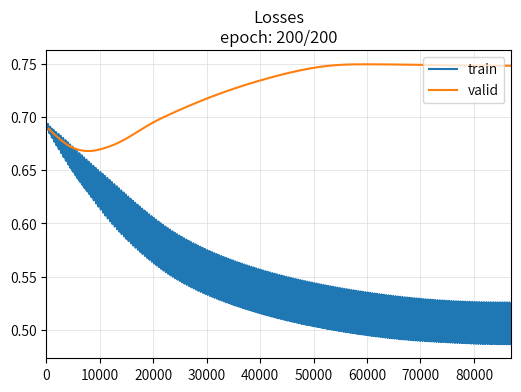

<Figure size 2000x400 with 3 Axes>

Fold 0 finished. Logs saved to ./logs/MINIROCKET_MULTI_0.csv


<Figure size 2000x400 with 3 Axes>

Fold 1 finished. Logs saved to ./logs/MINIROCKET_MULTI_1.csv


<Figure size 2000x400 with 3 Axes>

Fold 2 finished. Logs saved to ./logs/MINIROCKET_MULTI_2.csv


<Figure size 2000x400 with 3 Axes>

Fold 3 finished. Logs saved to ./logs/MINIROCKET_MULTI_3.csv


<Figure size 2000x400 with 3 Axes>

Fold 4 finished. Logs saved to ./logs/MINIROCKET_MULTI_4.csv


In [13]:
save_path = './logs'   # 【修改1】单独建日志目录，避免生成隐藏文件
model_name = 'MINIROCKET_MULTI'

Path(save_path).mkdir(parents=True, exist_ok=True)   # 【修改2】确保日志目录存在
Path("./models").mkdir(parents=True, exist_ok=True)  # 【修改3】确保模型目录存在

for fold in tqdm(range(5)):

    mode = 'before_after'
    # mode = 'classes'

    save_filename = f'{save_path}/{model_name}_{fold}.csv'   # 【修改4】保存成清晰可见的 csv 文件名


    train_dict = dm.get_numpy_dataset(fold=fold, training=True)
    test_dict = dm.get_numpy_dataset(fold=fold, training=False)

    train_X = np.array(train_dict['data'], dtype=np.float32)
    train_X = (train_X - dm.mins) / (dm.maxs - dm.mins)
    train_X = np.nan_to_num(train_X, copy=False)

    test_X = np.array(test_dict['data'], dtype=np.float32)
    test_X = (test_X - dm.mins) / (dm.maxs - dm.mins)
    test_X = np.nan_to_num(test_X, copy=False)

    # train_Y = np.array(train_dict['target_class'])
    # test_Y = np.array(test_dict['target_class'])

    train_Y = np.array(train_dict['before_after'])
    test_Y = np.array(test_dict['before_after'])

    splits = [list(np.arange(len(train_Y)))]
    splits.append(list(np.arange(len(test_Y)) + len(train_Y)))

    torch.cuda.empty_cache()

    # add seed
    set_seed(SEED)

    mrf = MiniRocketFeatures(train_X.shape[1], train_X.shape[2]).to(default_device())

    chunksize = 256   # 【修改7】从64调到256，A800通常更合适；如果显存不够再改回64

    mrf.fit(train_X, chunksize=chunksize)


    X_feat = get_minirocket_features(
        np.concatenate([train_X, test_X]),
        mrf,
        chunksize=chunksize,
        to_np=True
    )

    Y = np.concatenate([train_Y, test_Y])

    PATH = Path(f"./models/MRF_fold{fold}.pt")   # 【修改10】每折单独保存，不覆盖
    torch.save(mrf.state_dict(), PATH)

    tfms = [None, TSClassification()]
    batch_tfms = TSStandardize(by_sample=True)

    dls = get_ts_dls(
        X_feat,
        Y,
        splits=splits,
        tfms=tfms,
        batch_tfms=batch_tfms,
        shuffle=False
    )


    model = build_ts_model(MiniRocketHead, dls=dls)


    learn = Learner(
        dls,
        model,
        metrics=accuracy,
        cbs=[ShowGraph(), CSVLogger(fname=save_filename)]   # 【修改13】显式指定 csv 文件
    )


    results = learn.fit_one_cycle(200, 2.5e-5)


    # 【修改15】额外保存每折最终 recorder 数据，便于后续画图/统计
    hist_df = learn.recorder.values
    cols = [h.name if hasattr(h, 'name') else str(h) for h in learn.recorder.metric_names[1:-1]]
    hist_df = pd.DataFrame(hist_df, columns=cols)
    hist_df.to_csv(f'{save_path}/{model_name}_{fold}_recorder.csv', index=False)

    print(f"Fold {fold} finished. Logs saved to {save_filename}")